<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 12 </b></center>
<pre>    

# Step 1: Import Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import make_blobs , make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Step 2: Generate dummy data using make_blobs

In [15]:
x, y = make_blobs(n_samples=10,centers=3,random_state=42,cluster_std=1,)
x
y


array([2, 2, 1, 2, 0, 0, 0, 1, 1, 0])

# Step 3: Plot Generated data 

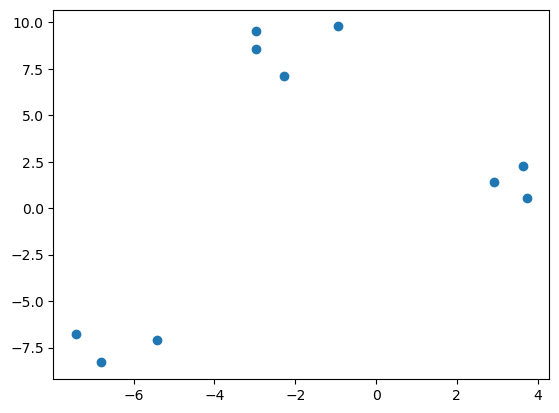

In [17]:
plt.scatter(x[:,0],x[:,1])
plt.show()

# Step 4: Apply Hierarchical Clustering

In [19]:
from sklearn.cluster import AgglomerativeClustering

In [21]:
model= AgglomerativeClustering(n_clusters=4,)

In [27]:
y_predicted =model.fit_predict(x)
y_predicted

array([1, 1, 2, 1, 0, 0, 3, 2, 2, 0], dtype=int64)

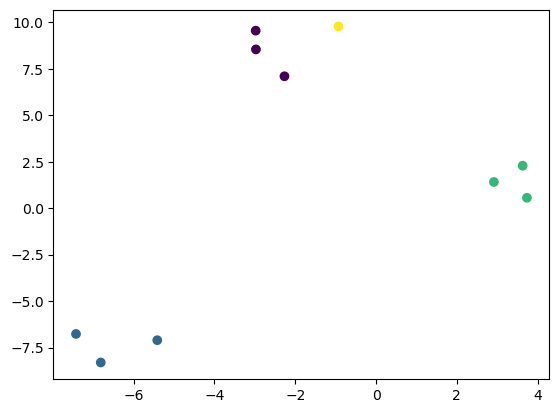

In [29]:
plt.scatter(x[:,0],x[:,1],c=y_predicted,)
plt.show()

# Step 5: Display Dendrogram

<function matplotlib.pyplot.show(close=None, block=None)>

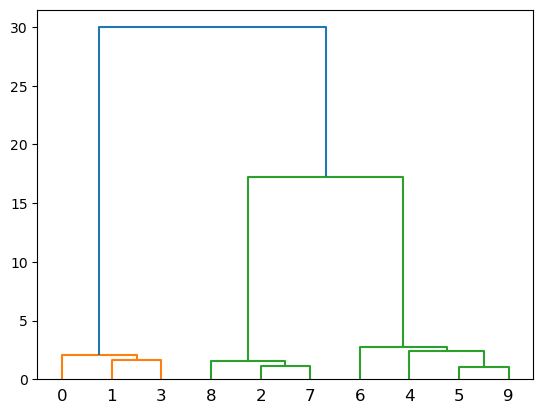

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(x,method='ward',)
dendrogram(linked)
plt.show

# Step 6: Generate dummy data using make_moons

In [49]:
x, y = make_moons(n_samples=300, noise=0.09, random_state=50)
x = StandardScaler().fit_transform(x)

# Step 7: Plot Generated data

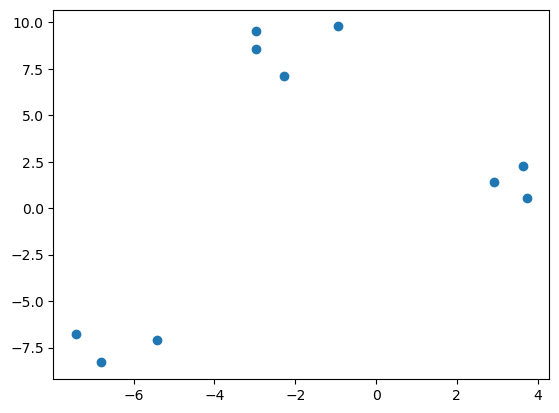

In [47]:
plt.scatter(x[:,0],x[:,1],)
plt.show()

# Step 8: apply DBSCAN Clustering 

In [51]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2,min_samples=5)
dbscan_predicted= dbscan.fit_predict(x)

In [55]:
dbscan_predicted

array([ 0,  1,  0,  0,  1,  1,  1,  0,  1,  1,  1,  2,  2,  1,  0,  0,  1,
        0,  0,  1,  1,  1,  3,  3,  0, -1,  1,  4,  0,  1,  1,  1,  1,  3,
        1,  1,  0,  0,  2,  0,  0,  3,  0,  3, -1,  0,  1,  0,  0,  1,  1,
        3,  3,  2, -1,  1,  1,  0,  0,  0,  2,  1,  1,  0,  0,  1,  1,  0,
        1,  0, -1,  1,  1,  3,  0,  0, -1,  0,  1,  1,  0, -1,  4,  1,  0,
        3,  1,  1,  1,  0,  0,  4,  2,  1,  0,  0,  4,  0,  4,  1,  1,  0,
        0,  1,  1,  1,  1,  0,  0,  2,  0,  4,  0,  3,  0,  0,  0, -1,  0,
        1,  0,  1,  1,  0,  4,  2,  0,  1,  0,  1,  1,  0,  3,  0,  0,  1,
        0,  1,  2,  0,  0,  4,  4,  0,  4,  0,  3,  1,  1,  3,  0,  1,  1,
        0,  0,  1,  1, -1,  0,  0,  4,  1,  0,  1,  0, -1,  1,  3,  0,  1,
        0,  0,  1,  0,  4,  3,  2,  4,  0, -1,  0,  3,  1,  2,  0,  0,  3,
        1,  0,  0,  3,  4,  3,  1,  1,  1,  2,  1,  0,  1,  1,  0,  0,  3,
        1,  0,  0,  0,  1,  3,  1,  0,  0,  0,  1,  1,  0,  0,  0,  1,  3,
        1,  1,  1,  0,  1

# Step 9: apply K Mean Clustering on same data

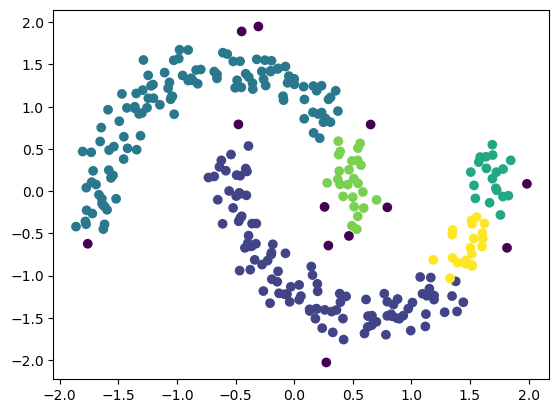

In [57]:
plt.scatter(x[:,0],x[:,1],c= dbscan_predicted,)

# Mall Customers Segmentation using DBSCAN

### Perform Following steps on Dataset for  customer segmentation
-> Load & Explore the Dataset <br>
-> Data Preprocessing <br>
-> Apply DBSCAN <br>
-> Visualizing Customer Segments <br>
-> Outliers (high-spending VIP customers or unusual shoppers <br>

In [59]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [63]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [67]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

In [69]:
df['Cluster'] = clusters
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


In [71]:
print("Unique clusters:", np.unique(clusters))
print("Number of clusters:", len(set(clusters)) - (1 if -1 in clusters else 0))
print("Noise points:", list(clusters).count(-1))

Unique clusters: [-1  0  1]
Number of clusters: 2
Noise points: 8


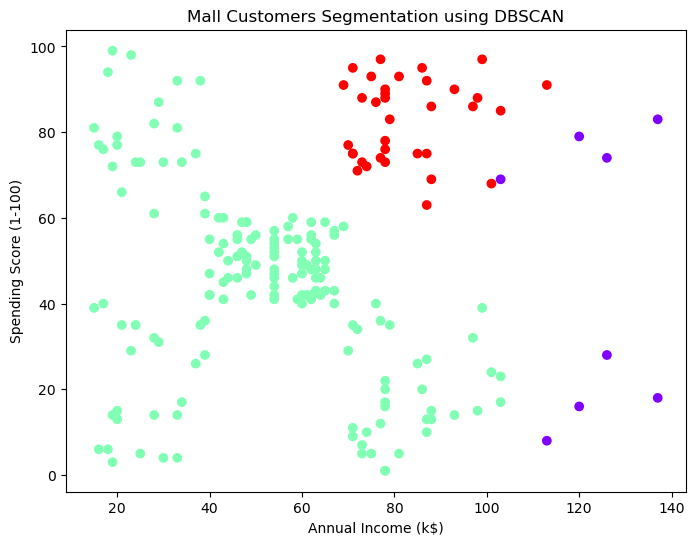

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'],
            cmap='rainbow')

plt.title("Mall Customers Segmentation using DBSCAN")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()